# Negotiation Arena: Human and LLM Negotiation Dynamics

This project investigates negotiation dynamics in human and LLM-based bargaining settings.

The project uses the Negochat corpus as a human negotiation baseline and compares it with two LLM-based experiments:

1. controlled LLM-to-LLM negotiations under cooperative, competitive, and mixed conditions;
2. human-seeded LLM continuations, where LLM agents continue from the first substantive negotiation act of real Negochat dialogues.

## Research Question

How do cooperative, competitive, and mixed negotiation styles influence agreement rates and negotiation efficiency in LLM-to-LLM bargaining simulations, and how do these dynamics compare to human negotiation patterns?

## Experimental Design

The project is organized into three levels of analysis.

### 1. Human baseline

The Negochat corpus is used as the human negotiation baseline. The corpus contains job contract negotiation dialogues annotated with dialogue acts such as Offer, Accept, Reject, Query, Greet, Quit, and Other.

### 2. Controlled LLM simulations

In the controlled LLM experiment, two LLM agents, Candidate and Employer, negotiate salary and working hours under three conditions:

- cooperative;
- competitive;
- mixed.

The goal is to test whether different prompting strategies affect agreement rate and negotiation length.

### 3. Human-seeded LLM continuations

In the human-seeded experiment, LLM agents start from the first substantive negotiation act of real Negochat dialogues. This allows a more direct comparison between human negotiation trajectories and LLM-generated continuations.

The controlled experiment studies the effect of negotiation style. The human-seeded experiment studies whether LLM agents can continue human-like negotiation contexts.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_or_create_human_data

from src.metrics import (
    compute_transition_matrix,
    compute_agreement_rate_by_condition,
    compute_average_turns_by_condition
)

from src.visualization import (
    plot_transition_heatmap,
    plot_outcomes_by_condition,
    plot_average_turns_by_condition
)

## Data Loading

This section loads all datasets used in the final analysis:

- the processed human Negochat dataframe;
- the controlled LLM simulation results;
- the human-seeded LLM continuation results.

The human dataset is loaded through the project data loader. If the processed CSV already exists, it is loaded directly. Otherwise, it can be regenerated from the raw Negochat JSON files.

In [2]:
human_df = load_or_create_human_data(
    raw_path="../data/raw/negochat",
    processed_path="../data/processed/human_negotiations.csv"
)

llm_turns = pd.read_csv("../results/llm_turns_colab.csv")
llm_outcomes = pd.read_csv("../results/llm_outcomes_colab.csv")

seeded_turns = pd.read_csv("../results/human_seeded_llm_turns_sample.csv")
seeded_outcomes = pd.read_csv("../results/human_seeded_llm_outcomes_sample.csv")

print("Human data:", human_df.shape)
print("Controlled LLM turns:", llm_turns.shape)
print("Controlled LLM outcomes:", llm_outcomes.shape)
print("Human-seeded LLM turns:", seeded_turns.shape)
print("Human-seeded LLM outcomes:", seeded_outcomes.shape)

Human data: (4993, 8)
Controlled LLM turns: (254, 9)
Controlled LLM outcomes: (27, 5)
Human-seeded LLM turns: (360, 9)
Human-seeded LLM outcomes: (20, 8)


In [3]:
human_df.head()

,dialogue_id,split,turn_id,role,text,act,issue,value
0,0,train,0,Candidate,Hello. I would like to discuss the issues of m...,Greet,NaN,True
1,0,train,1,Candidate,I would like a position of project manager,Offer,Job Description,Project Manager
2,0,train,2,Employer,We do not have any project manager positions o...,Reject,Job Description,Project Manager
3,0,train,3,Candidate,I want a position of project manager,Offer,Job Description,Project Manager
4,0,train,4,Employer,I do have programmer positions open with a str...,Offer,Job Description,Programmer


In [4]:
llm_outcomes.head()

,scenario_id,condition,run_id,outcome,n_turns
0,1,cooperative,0,Agreement,5
1,1,cooperative,1,Timeout,12
2,1,cooperative,2,Timeout,12
3,1,competitive,0,Failure,10
4,1,competitive,1,Failure,2


In [5]:
seeded_outcomes.head()

,dialogue_id,outcome,n_turns,human_original_turns,seed_role,seed_act,seed_issue,seed_value
0,78,Agreement,21,47,Candidate,Offer,Job Description,Project Manager
1,17,Impasse,21,48,Candidate,Offer,Salary,"120,000 USD"
2,100,Agreement,17,43,Candidate,Offer,Job Description,Project Manager
3,9,Impasse,21,23,Candidate,Offer,Salary,"120,000 USD"
4,36,Impasse,19,18,Candidate,Offer,Job Description,Project Manager


In [6]:
human_df.columns, llm_outcomes.columns, seeded_outcomes.columns

(Index(['dialogue_id', 'split', 'turn_id', 'role', 'text', 'act', 'issue',
        'value'],
       dtype='str'),
 Index(['scenario_id', 'condition', 'run_id', 'outcome', 'n_turns'], dtype='str'),
 Index(['dialogue_id', 'outcome', 'n_turns', 'human_original_turns',
        'seed_role', 'seed_act', 'seed_issue', 'seed_value'],
       dtype='str'))

## Human Baseline: Negochat Corpus

The human baseline is based on the processed Negochat corpus. Each row corresponds to a dialogue act extracted from the original JSON files.

The most important columns are:

- `dialogue_id`: identifies the negotiation dialogue;
- `turn_id`: identifies the position of the utterance in the dialogue;
- `role`: Candidate or Employer;
- `text`: natural language utterance;
- `act`: annotated dialogue act;
- `issue`: negotiation issue;
- `value`: proposed or discussed value.

This section describes how human negotiators behave in the original corpus.

In [7]:
human_act_counts = human_df["act"].value_counts()
human_act_counts

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

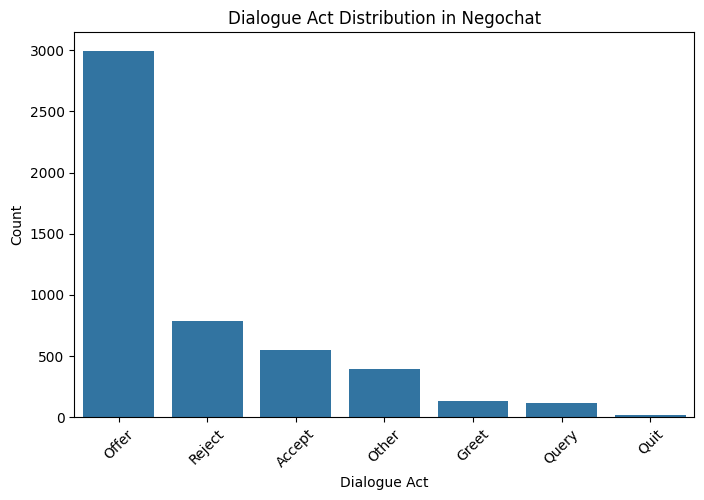

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=human_df,
    x="act",
    order=human_df["act"].value_counts().index
)

plt.title("Dialogue Act Distribution in Negochat")
plt.xlabel("Dialogue Act")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of dialogue acts shows which communicative actions are most frequent in human negotiations. Offers are expected to dominate, because negotiation is mainly structured around proposals and counter-proposals. Reject and Accept acts are also important because they indicate bargaining tension and agreement formation.

In [9]:
human_issue_counts = human_df["issue"].value_counts()
human_issue_counts

issue
Working Hours              865
Salary                     852
Job Description            685
Leased Car                 573
Pension Fund               406
Promotion Possibilities    274
Offer                       64
Name: count, dtype: int64

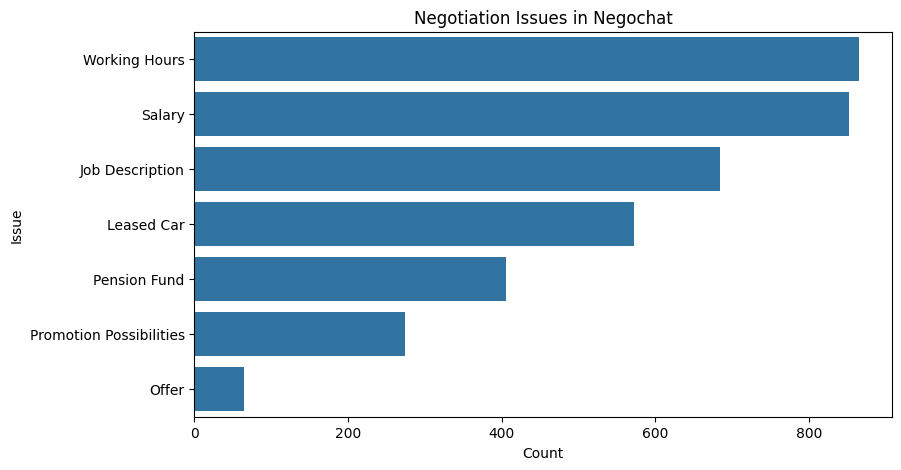

In [10]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=human_df,
    y="issue",
    order=human_df["issue"].value_counts().index
)

plt.title("Negotiation Issues in Negochat")
plt.xlabel("Count")
plt.ylabel("Issue")
plt.show()

The issue distribution shows which contract dimensions are most frequently negotiated by humans. Negochat contains multiple negotiation issues, including job description, salary, working hours, pension fund, leased car, and promotion possibilities. This makes the human corpus richer than the controlled LLM simulations, which focus mainly on salary and working hours.

In [11]:
human_role_act_table = human_df.groupby(["role", "act"]).size().unstack(fill_value=0)
human_role_act_table

act,Accept,Greet,Offer,Other,Query,Quit,Reject
role,,,,,,,
Candidate,298,105,1704,284,34,0,542
Employer,249,30,1292,110,79,18,248


This table compares the dialogue act usage of Candidates and Employers. It helps identify whether the two roles behave differently, for example whether one role produces more offers, rejections, or acceptance acts.

In [12]:
human_dialogue_lengths = human_df.groupby("dialogue_id")["turn_id"].nunique()
human_dialogue_lengths.describe()

count    105.000000
mean      34.514286
std       16.407734
min        8.000000
25%       23.000000
50%       30.000000
75%       44.000000
max      103.000000
Name: turn_id, dtype: float64

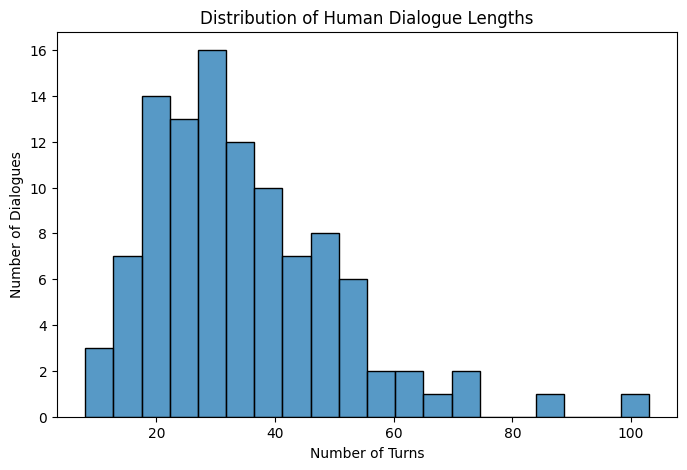

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    human_dialogue_lengths,
    bins=20
)

plt.title("Distribution of Human Dialogue Lengths")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Dialogues")
plt.show()

Dialogue length is used as a measure of negotiation complexity. Longer dialogues usually indicate more extended bargaining, more unresolved issues, or more complex agreement formation.

In [14]:
human_transition_matrix = compute_transition_matrix(human_df)
human_transition_matrix

next_act,Accept,Greet,Offer,Other,Query,Quit,Reject
current_act,,,,,,,
Accept,2,0,281,231,7,0,0
Greet,5,0,123,1,3,0,3
Offer,516,30,1524,108,51,10,743
Other,3,0,296,17,17,1,4
Query,0,0,94,10,2,1,4
Quit,0,0,7,5,2,0,0
Reject,21,0,671,22,31,6,36


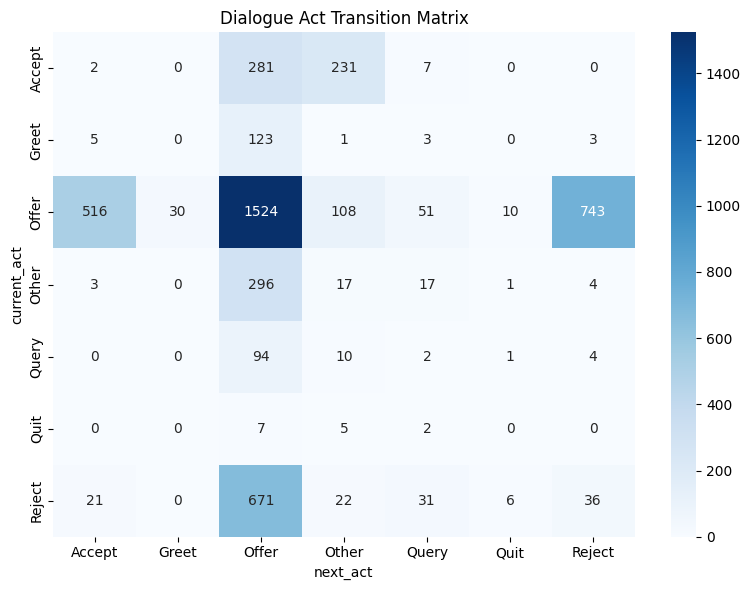

In [15]:
plot_transition_heatmap(human_transition_matrix)

The transition matrix shows how dialogue acts follow each other in human negotiations. For example, Offer → Offer indicates counteroffers, while Offer → Reject and Reject → Offer represent bargaining cycles.

## Human Outcome Inference

The original processed dataframe does not contain a direct outcome column. Therefore, outcomes are inferred from dialogue acts:

- if a dialogue contains at least one Accept act, it is classified as Agreement;
- if it contains a Quit act but no Accept, it is classified as Failure;
- otherwise, it is classified as Unresolved.

This is a heuristic, but it allows a consistent comparison with the LLM experiments.

In [16]:
def infer_human_outcome(group):
    acts = group["act"].tolist()

    if "Accept" in acts:
        return "Agreement"

    if "Quit" in acts:
        return "Failure"

    return "Unresolved"

In [17]:
human_outcomes = (
    human_df
    .groupby("dialogue_id")
    .apply(lambda g: pd.Series({
        "outcome": infer_human_outcome(g),
        "n_turns": g["turn_id"].nunique()
    }))
    .reset_index()
)

human_outcomes.head()

,dialogue_id,outcome,n_turns
0,0,Agreement,55
1,1,Agreement,27
2,2,Agreement,16
3,3,Agreement,32
4,4,Agreement,34


In [18]:
human_outcomes["outcome"].value_counts()

outcome
Agreement     103
Failure         1
Unresolved      1
Name: count, dtype: int64

In [19]:
human_outcome_percentages = (
    human_outcomes["outcome"]
    .value_counts(normalize=True)
    .mul(100)
)

human_outcome_percentages

outcome
Agreement     98.095238
Failure        0.952381
Unresolved     0.952381
Name: proportion, dtype: float64

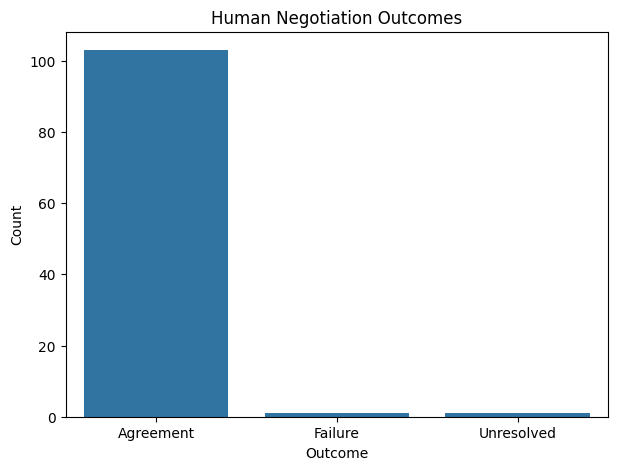

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=human_outcomes,
    x="outcome",
    order=human_outcomes["outcome"].value_counts().index
)

plt.title("Human Negotiation Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

The inferred human outcomes provide a baseline for comparison with LLM-generated negotiations. Since this outcome classification is inferred from annotated dialogue acts, it should be interpreted as an approximate but useful measure of negotiation resolution.

## Controlled LLM Negotiation Simulations

The controlled LLM experiment simulates two agents:

- Candidate;
- Employer.

The agents negotiate salary and working hours under three prompting conditions:

- cooperative;
- competitive;
- mixed.

The model used for these simulations was `TinyLlama/TinyLlama-1.1B-Chat-v1.0` through Hugging Face Transformers on Google Colab GPU.

The purpose of this experiment is to test whether negotiation style affects agreement rate and negotiation length.

In [21]:
llm_outcomes["outcome"].value_counts()

outcome
Timeout      15
Agreement     7
Failure       5
Name: count, dtype: int64

In [22]:
llm_outcomes.groupby("condition")["outcome"].value_counts()

condition    outcome  
competitive  Timeout      5
             Failure      3
             Agreement    1
cooperative  Agreement    4
             Timeout      4
             Failure      1
mixed        Timeout      6
             Agreement    2
             Failure      1
Name: count, dtype: int64

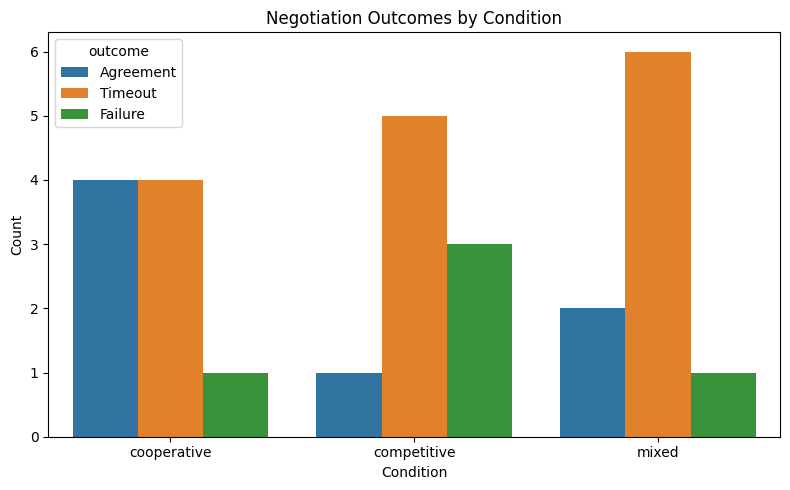

In [23]:
plot_outcomes_by_condition(llm_outcomes)

The outcome distribution shows whether different prompting conditions lead to different negotiation results. In particular, competitive settings are expected to produce more timeouts or impasses, while cooperative settings are expected to converge more easily.

In [24]:
llm_agreement_rates = compute_agreement_rate_by_condition(llm_outcomes)
llm_avg_turns = compute_average_turns_by_condition(llm_outcomes)

llm_summary = pd.DataFrame({
    "agreement_rate": llm_agreement_rates,
    "avg_turns": llm_avg_turns
})

llm_summary

,agreement_rate,avg_turns
condition,,
competitive,0.111111,10.111111
cooperative,0.444444,8.888889
mixed,0.222222,9.222222


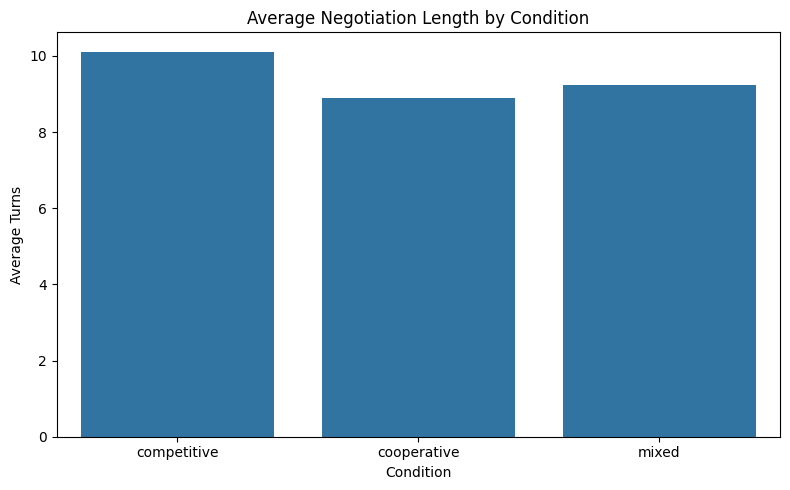

In [25]:
plot_average_turns_by_condition(llm_outcomes)

Average negotiation length is used as a measure of negotiation efficiency. Shorter negotiations indicate faster convergence, while longer negotiations suggest greater bargaining friction.

## Salary and Working-hours Analysis

The controlled LLM experiment logs salary and working-hours offers. These variables allow us to inspect whether different prompting conditions affect the concrete content of negotiation offers.

In [26]:
llm_turns.groupby("condition")["salary_offer"].mean()

condition
competitive    117704.352941
cooperative     92944.912281
mixed           96130.709091
Name: salary_offer, dtype: float64

In [27]:
llm_turns.groupby("condition")["hours_offer"].mean()

condition
competitive    8.188889
cooperative    8.392157
mixed          9.875000
Name: hours_offer, dtype: float64

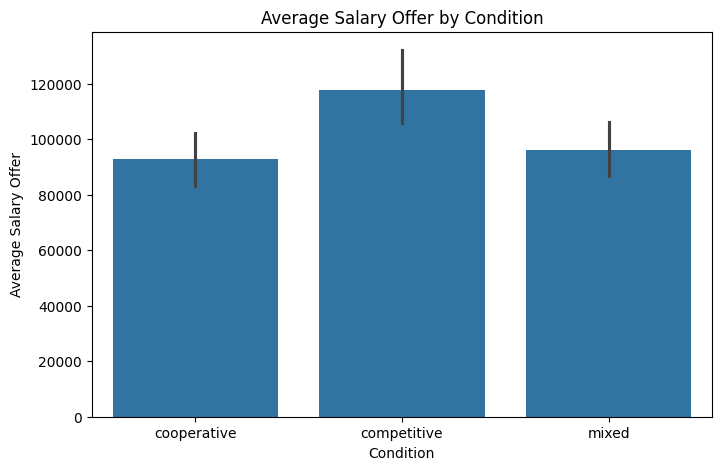

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=llm_turns,
    x="condition",
    y="salary_offer",
    estimator="mean"
)

plt.title("Average Salary Offer by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Salary Offer")
plt.show()

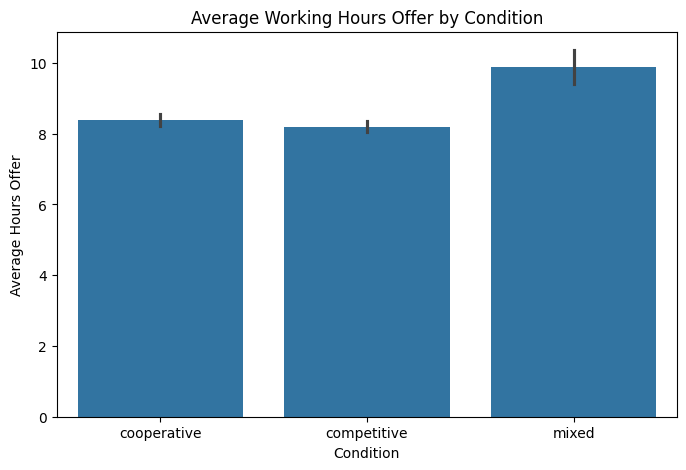

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=llm_turns,
    x="condition",
    y="hours_offer",
    estimator="mean"
)

plt.title("Average Working Hours Offer by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Hours Offer")
plt.show()

Salary and working-hours offers provide a more detailed view of negotiation behavior. Cooperative conditions may produce more balanced offers, while competitive conditions may show stronger resistance on salary or working hours.

## Human vs Controlled LLM Comparison

This section compares the original human negotiations with the controlled LLM simulations.

This comparison must be interpreted carefully because the two settings are not identical:

- Negochat contains full multi-issue negotiations;
- the controlled LLM experiment focuses only on salary and working hours;
- the controlled LLM experiment uses explicit stopping rules and a maximum number of turns.

Nevertheless, the comparison is useful for understanding whether LLM negotiations are more compressed, structured, or dependent on prompt constraints.

In [30]:
human_avg_turns = human_outcomes["n_turns"].mean()
controlled_llm_avg_turns = llm_outcomes["n_turns"].mean()

comparison_turns = pd.DataFrame({
    "source": ["Human Negochat", "Controlled LLM Agents"],
    "avg_turns": [human_avg_turns, controlled_llm_avg_turns]
})

comparison_turns

,source,avg_turns
0,Human Negochat,34.514286
1,Controlled LLM Agents,9.407407


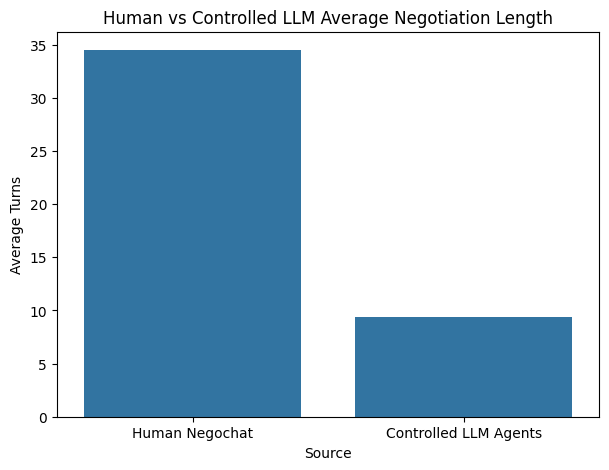

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison_turns,
    x="source",
    y="avg_turns"
)

plt.title("Human vs Controlled LLM Average Negotiation Length")
plt.xlabel("Source")
plt.ylabel("Average Turns")
plt.show()

Human negotiations are substantially longer than the controlled LLM simulations. This is expected because Negochat contains full multi-issue job negotiations, while the controlled LLM simulations were constrained to salary and working hours with a maximum number of turns. Without explicit stopping rules, LLM agents often tend to continue negotiating rather than reaching a clear terminal state.

## Human-seeded LLM Continuation Experiment

The controlled LLM experiment is useful for testing prompting conditions, but it starts from synthetic negotiation prompts. To make the comparison with humans more direct, an additional human-seeded experiment was conducted.

In this experiment, each LLM simulation starts from the first substantive negotiation act of a sampled Negochat dialogue. Greetings and purely introductory turns are skipped. The seed act is usually an Offer, Reject, Query, or Accept.

This experiment asks:

Can LLM agents continue a negotiation from a real human negotiation move?

In [32]:
seeded_outcomes.head()

,dialogue_id,outcome,n_turns,human_original_turns,seed_role,seed_act,seed_issue,seed_value
0,78,Agreement,21,47,Candidate,Offer,Job Description,Project Manager
1,17,Impasse,21,48,Candidate,Offer,Salary,"120,000 USD"
2,100,Agreement,17,43,Candidate,Offer,Job Description,Project Manager
3,9,Impasse,21,23,Candidate,Offer,Salary,"120,000 USD"
4,36,Impasse,19,18,Candidate,Offer,Job Description,Project Manager


In [33]:
seeded_outcomes["outcome"].value_counts()

outcome
Impasse      11
Agreement     9
Name: count, dtype: int64

In [34]:
seeded_outcomes["outcome"].value_counts(normalize=True).mul(100)

outcome
Impasse      55.0
Agreement    45.0
Name: proportion, dtype: float64

In [35]:
seeded_outcomes[["n_turns", "human_original_turns"]].describe()

,n_turns,human_original_turns
count,20.000000,20.000000
mean,18.000000,29.650000
std,3.741657,12.175363
min,10.000000,12.000000
25%,16.500000,20.750000
50%,20.000000,27.000000
75%,21.000000,37.750000
max,21.000000,55.000000


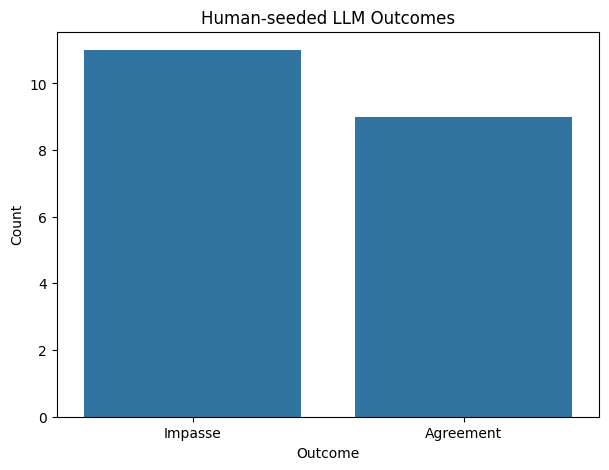

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=seeded_outcomes,
    x="outcome",
    order=seeded_outcomes["outcome"].value_counts().index
)

plt.title("Human-seeded LLM Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

The human-seeded experiment often produces Impasse outcomes. This means that the LLM agents do not explicitly quit the negotiation, but the interaction becomes stuck without reaching agreement. This is different from Failure, which would require an explicit Quit act or quit decision.

In [37]:
seeded_length_comparison = seeded_outcomes[[
    "dialogue_id",
    "n_turns",
    "human_original_turns"
]].copy()

seeded_length_long = seeded_length_comparison.melt(
    id_vars="dialogue_id",
    value_vars=["n_turns", "human_original_turns"],
    var_name="source",
    value_name="turns"
)

seeded_length_long["source"] = seeded_length_long["source"].replace({
    "n_turns": "LLM continuation",
    "human_original_turns": "Original human dialogue"
})

seeded_length_long.head()

,dialogue_id,source,turns
0,78,LLM continuation,21
1,17,LLM continuation,21
2,100,LLM continuation,17
3,9,LLM continuation,21
4,36,LLM continuation,19


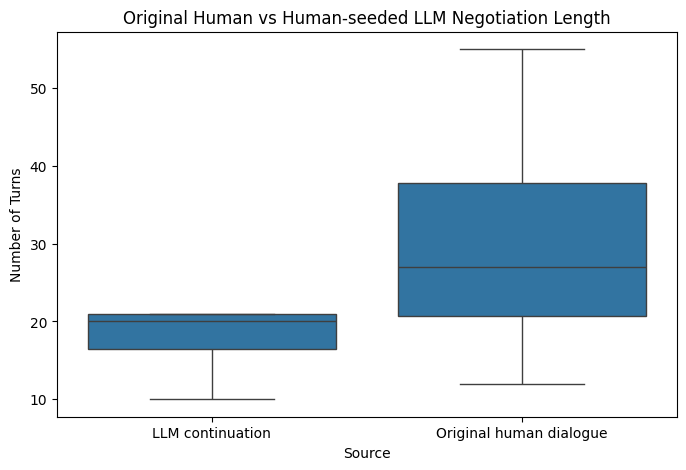

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=seeded_length_long,
    x="source",
    y="turns"
)

plt.title("Original Human vs Human-seeded LLM Negotiation Length")
plt.xlabel("Source")
plt.ylabel("Number of Turns")
plt.show()

This comparison uses the same sampled dialogue IDs. The original human length represents the full human negotiation, while the LLM continuation length represents how long the LLM agents continued after the first substantive human negotiation act.

## LLM Dialogue Act Analysis

The human Negochat corpus contains annotated dialogue acts.  
For the human-seeded LLM experiment, dialogue acts were generated by the model itself using the structured field `ACT`.

This allows a direct comparison between human and LLM communicative behavior.

In [48]:
seeded_turns["act"].value_counts()

act
Offer     216
Query     116
Accept      9
Reject      6
Other       5
Name: count, dtype: int64

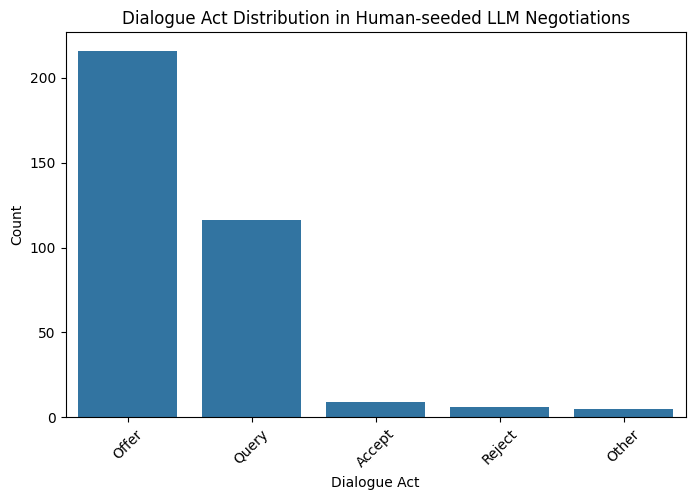

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=seeded_turns,
    x="act",
    order=seeded_turns["act"].value_counts().index
)

plt.title("Dialogue Act Distribution in Human-seeded LLM Negotiations")
plt.xlabel("Dialogue Act")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Paired Human vs Human-seeded LLM Comparison

The previous comparison looked at general distributions. Here, the comparison is restricted to the exact same dialogue IDs used in the human-seeded experiment.

This is a more direct comparison because each LLM continuation is linked to a specific original human negotiation.

In [39]:
sample_ids = seeded_outcomes["dialogue_id"].astype(str).unique()

human_sample_outcomes = human_outcomes[
    human_outcomes["dialogue_id"].astype(str).isin(sample_ids)
].copy()

seeded_outcomes_compare = seeded_outcomes.copy()

human_sample_outcomes["dialogue_id"] = human_sample_outcomes["dialogue_id"].astype(str)
seeded_outcomes_compare["dialogue_id"] = seeded_outcomes_compare["dialogue_id"].astype(str)

paired_comparison = human_sample_outcomes.merge(
    seeded_outcomes_compare,
    on="dialogue_id",
    suffixes=("_human", "_llm")
)

paired_comparison.head()

,dialogue_id,outcome_human,n_turns_human,outcome_llm,n_turns_llm,human_original_turns,seed_role,seed_act,seed_issue,seed_value
0,2,Agreement,16,Agreement,13,16,Candidate,Offer,Salary,"120,000 USD"
1,3,Agreement,32,Agreement,17,32,Candidate,Offer,Salary,"120,000 USD"
2,9,Agreement,23,Impasse,21,23,Candidate,Offer,Salary,"120,000 USD"
3,14,Agreement,27,Agreement,17,27,Candidate,Offer,Job Description,Project Manager
4,16,Agreement,14,Impasse,15,14,Candidate,Offer,Job Description,Project Manager


In [40]:
paired_comparison[[
    "dialogue_id",
    "outcome_human",
    "outcome_llm",
    "n_turns_human",
    "n_turns_llm"
]]

,dialogue_id,outcome_human,outcome_llm,n_turns_human,n_turns_llm
0,2,Agreement,Agreement,16,13
1,3,Agreement,Agreement,32,17
2,9,Agreement,Impasse,23,21
3,14,Agreement,Agreement,27,17
4,16,Agreement,Impasse,14,15
5,17,Agreement,Impasse,48,21
6,29,Agreement,Impasse,35,21
7,30,Agreement,Impasse,37,21
8,32,Agreement,Agreement,27,21
9,36,Agreement,Impasse,18,19


In [41]:
human_sample_dist = (
    paired_comparison["outcome_human"]
    .value_counts(normalize=True)
    .mul(100)
)

llm_seeded_dist = (
    paired_comparison["outcome_llm"]
    .value_counts(normalize=True)
    .mul(100)
)

human_seeded_outcome_comparison = pd.DataFrame({
    "Human original": human_sample_dist,
    "LLM continuation": llm_seeded_dist
}).fillna(0)

human_seeded_outcome_comparison

,Human original,LLM continuation
Agreement,95.0,45.0
Failure,5.0,0.0
Impasse,0.0,55.0


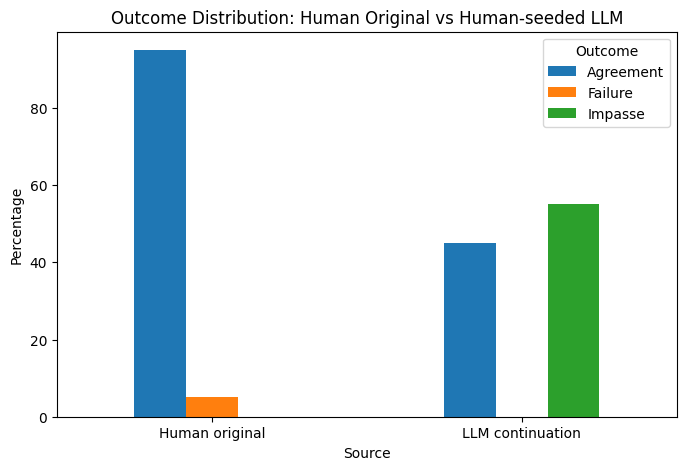

In [42]:
human_seeded_outcome_comparison.T.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Outcome Distribution: Human Original vs Human-seeded LLM")
plt.ylabel("Percentage")
plt.xlabel("Source")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.show()

The paired comparison shows whether LLM continuations from human negotiation acts lead to similar or different outcomes compared with the original human dialogues.

If human dialogues show more agreements while LLM continuations show more impasses, this suggests that LLM agents can reproduce local negotiation moves but may struggle with global negotiation closure.

In [50]:
human_act_percentages = (
    human_df["act"]
    .value_counts(normalize=True)
    .mul(100)
)

llm_seeded_act_percentages = (
    seeded_turns["act"]
    .value_counts(normalize=True)
    .mul(100)
)

act_comparison = pd.DataFrame({
    "Human Negochat": human_act_percentages,
    "Human-seeded LLM": llm_seeded_act_percentages
}).fillna(0)

act_comparison

,Human Negochat,Human-seeded LLM
act,,
Accept,10.955337,2.556818
Greet,2.703785,0.000000
Offer,60.004006,61.363636
Other,7.891047,1.420455
Query,2.263168,32.954545
Quit,0.360505,0.000000
Reject,15.822151,1.704545


In [51]:
seeded_turns_for_transitions = seeded_turns.rename(
    columns={"turn": "turn_id"}
)

seeded_transition_matrix = compute_transition_matrix(
    seeded_turns_for_transitions
)

seeded_transition_matrix

next_act,Accept,Offer,Other,Query,Reject
current_act,,,,,
Offer,9,93,3,98,6
Other,0,1,0,4,0
Query,0,96,2,6,0
Reject,0,4,0,2,0


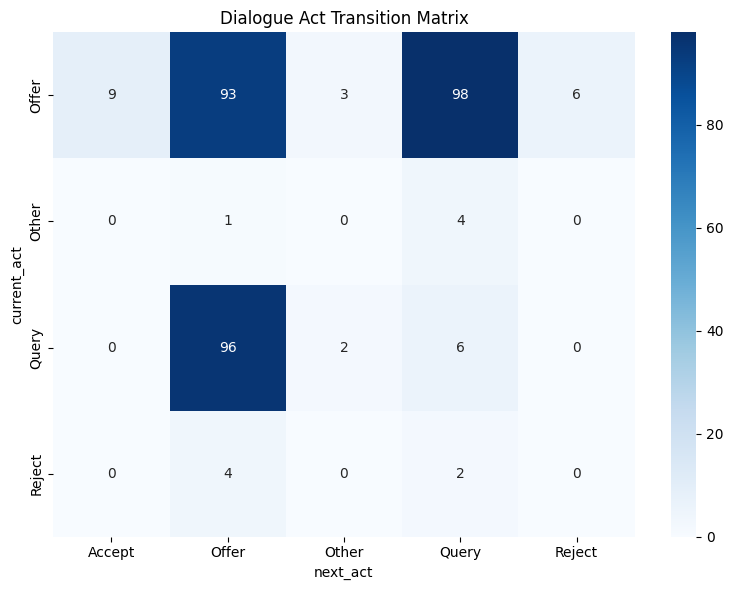

In [52]:
plot_transition_heatmap(seeded_transition_matrix)

The LLM transition matrix shows how model-generated acts follow each other.  
Comparing this matrix with the human transition matrix helps identify whether LLM agents reproduce human-like bargaining cycles such as Offer → Reject, Reject → Offer, and Offer → Offer.

Compared with human negotiations, LLM continuations tend to show a more limited dialogue act repertoire. Human dialogues contain a wider range of transitions, while LLM-generated negotiations often concentrate around Offer, Reject, Query, and Impasse-related continuation patterns.

This suggests that LLM agents can reproduce local bargaining moves, but their dialogue dynamics are less diverse than human negotiation behavior.

## Qualitative Examples

Quantitative metrics are useful, but negotiation is also a pragmatic and conversational task. Therefore, qualitative inspection is important.

The following examples show how LLM agents continue from human negotiation seeds.

In [43]:
example_dialogue_id = seeded_outcomes["dialogue_id"].astype(str).iloc[0]

example = seeded_turns[
    seeded_turns["dialogue_id"].astype(str) == example_dialogue_id
][["turn", "speaker", "act", "decision", "text"]]

example

,turn,speaker,act,decision,text
0,0,Candidate,Offer,seed,I want a position of project manager
1,1,Employer,Offer,continue,MESSAGE: We currently don't have any open posi...
2,2,Candidate,Query,continue,"MESSAGE: While I appreciate the consideration,..."
3,3,Employer,Offer,continue,"MESSAGE: We understand your concerns, and we'r..."
4,4,Candidate,Query,continue,MESSAGE: I'm intrigued by the development team...
5,5,Employer,Offer,continue,"MESSAGE: As the development team lead, you wou..."
6,6,Candidate,Query,continue,MESSAGE: While I appreciate the details on the...
7,7,Employer,Offer,continue,MESSAGE: We're willing to revisit the job desc...
8,8,Candidate,Offer,continue,MESSAGE: I appreciate your willingness to revi...
9,9,Employer,Offer,continue,MESSAGE: We're happy to revisit the salary dis...


In [44]:
for _, row in example.iterrows():
    print("-" * 80)
    print(f'Turn {row["turn"]} | {row["speaker"]} | Act: {row["act"]} | Decision: {row["decision"]}')
    print(row["text"])

--------------------------------------------------------------------------------
Turn 0 | Candidate | Act: Offer | Decision: seed
I want a position of project manager
--------------------------------------------------------------------------------
Turn 1 | Employer | Act: Offer | Decision: continue
MESSAGE: We currently don't have any open positions for a project manager, but we do have a role available as an operations manager that could be a good fit. It comes with similar responsibilities and a slightly lower salary.
ACT: Offer
ISSUE: Job Description
VALUE: Operations Manager
DECISION: continue
--------------------------------------------------------------------------------
Turn 2 | Candidate | Act: Query | Decision: continue
MESSAGE: While I appreciate the consideration, I'm not sure the operations manager role aligns with my career goals. I'd like to discuss other possibilities that might better fit what I bring to the table.
ACT: Query
ISSUE: Job Description
VALUE: None
DECISION:

This qualitative example illustrates whether the LLM continuation remains coherent with the initial human negotiation act, whether it introduces new issues, and whether it reaches agreement, impasse, or timeout.

## Overall Comparison

The following table summarizes the three main sources of negotiation data:

- Human Negochat;
- Controlled LLM simulations;
- Human-seeded LLM continuations.

In [45]:
overall_summary = pd.DataFrame({
    "source": [
        "Human Negochat",
        "Controlled LLM",
        "Human-seeded LLM"
    ],
    "n_dialogues": [
        human_outcomes["dialogue_id"].nunique(),
        len(llm_outcomes),
        len(seeded_outcomes)
    ],
    "avg_turns": [
        human_outcomes["n_turns"].mean(),
        llm_outcomes["n_turns"].mean(),
        seeded_outcomes["n_turns"].mean()
    ],
    "main_outcome": [
        human_outcomes["outcome"].value_counts().idxmax(),
        llm_outcomes["outcome"].value_counts().idxmax(),
        seeded_outcomes["outcome"].value_counts().idxmax()
    ]
})

overall_summary

,source,n_dialogues,avg_turns,main_outcome
0,Human Negochat,105,34.514286,Agreement
1,Controlled LLM,27,9.407407,Timeout
2,Human-seeded LLM,20,18.000000,Impasse


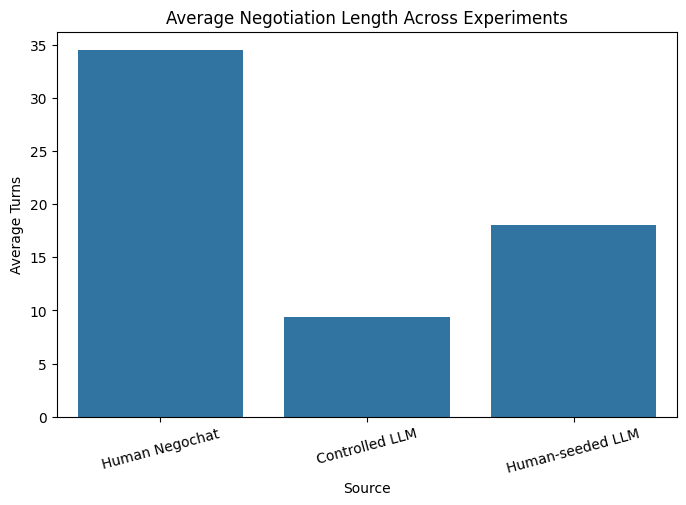

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=overall_summary,
    x="source",
    y="avg_turns"
)

plt.title("Average Negotiation Length Across Experiments")
plt.xlabel("Source")
plt.ylabel("Average Turns")
plt.xticks(rotation=15)
plt.show()

## Discussion

The results show that negotiation style influences LLM agent behavior. In the controlled LLM experiment, cooperative agents generally reach agreements faster, while competitive and mixed configurations tend to produce longer interactions and more negotiation friction.

Compared with the original human negotiations, controlled LLM simulations are shorter and more structured. This is partly due to the experimental design: LLM agents were constrained to negotiate salary and working hours, while Negochat dialogues include a broader set of issues such as job position, pension, promotion possibilities, leased car, and working hours.

The human-seeded continuation experiment provides a more direct comparison between humans and LLM agents. Starting from the first substantive negotiation act of real Negochat dialogues, LLM agents were able to generate locally plausible negotiation moves. However, unresolved cases often resulted in impasse rather than explicit failure. This suggests that LLM agents can reproduce local bargaining behavior, but may struggle with global negotiation closure.

A limitation of the LLM setup is that models sometimes produce inconsistent structured outputs or fail to explicitly accept valid offers. For this reason, external parsing and rule-based validation were used to evaluate outcomes. This does not replace the LLM behavior, but acts as an environment-level evaluator.

Another limitation is that the human-seeded experiment was run on a random sample of dialogues rather than the full corpus due to computational constraints. However, the fixed sampling procedure makes the experiment reproducible.

## Conclusion

This project implemented a negotiation arena for analyzing human and LLM negotiation dynamics.

The Negochat corpus was used as a human baseline, while LLM agents were simulated in two ways: through controlled prompting conditions and through human-seeded continuations from real negotiation acts.

Overall, the results suggest that LLM agents can generate realistic local negotiation moves such as offers, counteroffers, rejections, and questions. However, compared with human negotiations, LLM interactions are more dependent on prompt constraints, structured output formats, and external stopping rules.

The project highlights both the potential and the limitations of LLM-based agents for simulating pragmatic negotiation behavior. LLMs can imitate negotiation language, but they still require careful experimental control to produce interpretable and reliable outcomes.

##test 



In [53]:
print("Human data:", human_df.shape)
print("Controlled LLM outcomes:", llm_outcomes.shape)
print("Controlled LLM turns:", llm_turns.shape)
print("Seeded LLM outcomes:", seeded_outcomes.shape)
print("Seeded LLM turns:", seeded_turns.shape)

Human data: (4993, 8)
Controlled LLM outcomes: (27, 5)
Controlled LLM turns: (254, 9)
Seeded LLM outcomes: (20, 8)
Seeded LLM turns: (360, 9)


In [54]:
human_df["act"].value_counts()

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

In [55]:
seeded_turns["act"].value_counts()

act
Offer     216
Query     116
Accept      9
Reject      6
Other       5
Name: count, dtype: int64

In [56]:
human_outcomes["outcome"].value_counts()

outcome
Agreement     103
Failure         1
Unresolved      1
Name: count, dtype: int64

In [57]:
llm_outcomes["outcome"].value_counts()

outcome
Timeout      15
Agreement     7
Failure       5
Name: count, dtype: int64

In [58]:
llm_outcomes.groupby("condition")["outcome"].value_counts()

condition    outcome  
competitive  Timeout      5
             Failure      3
             Agreement    1
cooperative  Agreement    4
             Timeout      4
             Failure      1
mixed        Timeout      6
             Agreement    2
             Failure      1
Name: count, dtype: int64

In [59]:
llm_outcomes.groupby("condition")["n_turns"].mean()

condition
competitive    10.111111
cooperative     8.888889
mixed           9.222222
Name: n_turns, dtype: float64

In [60]:
seeded_outcomes["outcome"].value_counts()

outcome
Impasse      11
Agreement     9
Name: count, dtype: int64

In [61]:
seeded_outcomes[["n_turns", "human_original_turns"]].describe()

,n_turns,human_original_turns
count,20.000000,20.000000
mean,18.000000,29.650000
std,3.741657,12.175363
min,10.000000,12.000000
25%,16.500000,20.750000
50%,20.000000,27.000000
75%,21.000000,37.750000
max,21.000000,55.000000


In [62]:
paired_comparison[[
    "dialogue_id",
    "outcome_human",
    "outcome_llm",
    "n_turns_human",
    "n_turns_llm"
]]

,dialogue_id,outcome_human,outcome_llm,n_turns_human,n_turns_llm
0,2,Agreement,Agreement,16,13
1,3,Agreement,Agreement,32,17
2,9,Agreement,Impasse,23,21
3,14,Agreement,Agreement,27,17
4,16,Agreement,Impasse,14,15
5,17,Agreement,Impasse,48,21
6,29,Agreement,Impasse,35,21
7,30,Agreement,Impasse,37,21
8,32,Agreement,Agreement,27,21
9,36,Agreement,Impasse,18,19


In [63]:
overall_summary

,source,n_dialogues,avg_turns,main_outcome
0,Human Negochat,105,34.514286,Agreement
1,Controlled LLM,27,9.407407,Timeout
2,Human-seeded LLM,20,18.000000,Impasse
